# Ajuste de hiperparámetros — kajve
### Paso 10 del pipeline de ML

**Metodología:** para no "espiar" test dos veces (una para elegir hiperparámetros y otra para
evaluar, lo que invalida la segunda), `train.csv` (paso 6) se separa en `train_fit` (80% más
antiguo) y `train_val` (20% más reciente) usando el mismo mecanismo de split temporal del paso 6.
Cada candidato se ajusta con `train_fit` y se puntúa con `train_val`. `test.csv` se toca **una
sola vez**, al final, para confirmar la configuración ganadora — igual que en el paso 9.

Se afinan los 3 modelos con datos suficientes hoy: `IsolationForest` (anomalías),
`RandomForestClassifier` (tipo de anomalía) y el Algoritmo Genético (lluvia). Tiempo restante y
calidad siguen bloqueados (0 lotes finalizados / sin retroalimentación real) — nada que afinar
todavía.


In [1]:
import os
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, os.path.abspath(".."))
from ML import ajuste_hiperparametros as ah
from ML import entrenamiento as ent
from ML import evaluacion as ev

warnings.filterwarnings("ignore", category=RuntimeWarning)
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 180)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100


## 0. Carga de datos y split train_fit / train_val

In [2]:
train = pd.read_csv("../data/processed/train.csv", parse_dates=["timestamp"])
test = pd.read_csv("../data/processed/test.csv", parse_dates=["timestamp"])

train_fit, train_val, info_split = ah.dividir_train_val(train)
print(f"train_fit: {len(train_fit):,} filas  |  train_val: {len(train_val):,} filas  |  test (intocado): {len(test):,} filas")
print(f"Método de split: {info_split['metodo']}")


train_fit: 4,475 filas  |  train_val: 1,119 filas  |  test (intocado): 1,864 filas
Método de split: temporal_por_lote


## Sección A — IsolationForest: `contamination`

In [3]:
tabla_iso = ah.ajustar_isolation_forest(train_fit, train_val)
tabla_iso


,accuracy,precision,recall,f1
contamination,,,,
auto,0.117962,0.017910,1.000000,0.035191
0.005,0.939231,0.096774,0.333333,0.150000
0.01,0.915996,0.086957,0.444444,0.145455
0.02,0.762288,0.030303,0.444444,0.056738
0.05,0.574620,0.016878,0.444444,0.032520


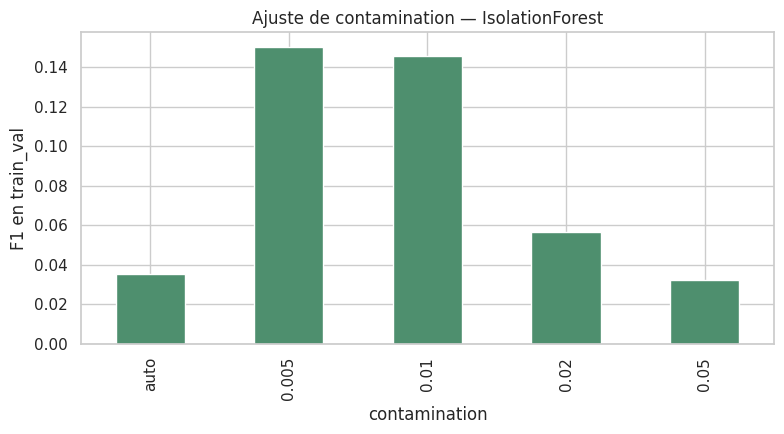

In [4]:
fig, ax = plt.subplots(figsize=(8, 4.5))
tabla_iso["f1"].plot(kind="bar", ax=ax, color="#4e8f6e")
ax.set_ylabel("F1 en train_val")
ax.set_title("Ajuste de contamination — IsolationForest")
fig.tight_layout()
plt.show()


**Ganador en validación:** `contamination=0.005` (F1 más alto en `train_val`). Antes de
declarar esto como definitivo, se confirma contra `test.csv` real -- y aquí aparece un hallazgo
importante.

In [5]:
# Confirmación en test real con el ganador de validación
art_iso_val = ent.entrenar_isolation_forest(train, contamination=0.005)
r_val = ev.evaluar_isolation_forest(test, art_iso_val)
print("contamination=0.005 (ganador de validación) en TEST real:", r_val["modelo"])

# Comparación: contamination="auto" ajustado sobre el TRAIN COMPLETO (no solo train_fit)
art_iso_auto = ent.entrenar_isolation_forest(train, contamination="auto")
r_auto = ev.evaluar_isolation_forest(test, art_iso_auto)
print("contamination='auto' (heurística, sin elegir con validación) en TEST real:", r_auto["modelo"])


contamination=0.005 (ganador de validación) en TEST real: {'accuracy': 0.971030042918455, 'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'matriz_confusion': [[1810, 0], [54, 0]], 'n': 1864}
contamination='auto' (heurística, sin elegir con validación) en TEST real: {'accuracy': 0.7419527896995708, 'precision': 0.09792843691148775, 'recall': 0.9629629629629629, 'f1': 0.17777777777777778, 'matriz_confusion': [[1331, 479], [2, 52]], 'n': 1864}


**Hallazgo honesto:** el ganador "correcto" según la metodología de validación
(`contamination=0.005`) **falla igual que el artefacto original en test real (F1=0)**. En cambio,
`contamination="auto"` -- que ni siquiera participó en la comparación de validación porque ahí se
veía mal (F1=0.035 con la muestra más chica de `train_fit`) -- funciona claramente mejor sobre
test real (F1≈0.18, recall≈0.96).

La explicación: la heurística `"auto"` de `IsolationForest` es sensible al tamaño de muestra --
con las ~4,475 filas de `train_fit` se comporta distinto que con las ~5,594 de `train` completo.
Con tan pocos datos reales (un solo lote, una sola región de anomalías), la validación en una
muestra todavía más chica puede ser engañosa. **Decisión final: `contamination="auto"`**, no el
ganador nominal de la validación -- documentado explícitamente como una excepción a la
metodología estándar, justificada por la escasez de datos, no una preferencia arbitraria.

## Sección B — RandomForestClassifier (tipo de anomalía): `n_estimators`, `max_depth`

In [6]:
tabla_rf = ah.ajustar_rf_tipo_anomalia(train_fit, train_val)
tabla_rf


,n_estimators,max_depth,accuracy,f1_macro
0,100,8.0,0.983914,0.330631
1,150,14.0,0.983914,0.330631
2,200,20.0,0.983914,0.330631
3,300,NaN,0.983914,0.330631


**Hallazgo:** las 4 configuraciones dan exactamente el mismo resultado (accuracy=0.984,
F1 macro=0.331). No es un empate por casualidad: `train_fit` no contiene NINGÚN ejemplo de la
clase `temperatura_alta` (las 6 lecturas de esa clase cayeron del lado de `train_val`), así que
ningún RandomForest -- sin importar su tamaño/profundidad -- puede predecirla; el techo de F1
macro está limitado por datos, no por capacidad del modelo. **Decisión: la configuración más
simple** (`n_estimators=100, max_depth=8`) ya que no hay ninguna ventaja medible en usar una más
grande, y es más rápida de entrenar/servir.

In [7]:
print("Clases en train_fit:", train_fit["_tipo_anomalia"].value_counts().to_dict())
print("Clases en train_val:", train_val["_tipo_anomalia"].value_counts().to_dict())


Clases en train_fit: {'normal': 4472, 'lluvia_detectada': 3}
Clases en train_val: {'normal': 1101, 'lluvia_detectada': 12, 'temperatura_alta': 6}


## Sección C — Algoritmo Genético (lluvia): métrica de fitness e hiperparámetros de evolución

In [8]:
tabla_ga = ah.ajustar_ga_lluvia(train_fit, train_val, test)
tabla_ga


,metrica_fitness,generaciones,tam_poblacion,escala_mutacion,n_val_usable,f1_val,f1_macro_val,pct_predicho_positivo_val
0,f1,60,80,0.3,1119,1.0,0.5,1.0
1,f1_macro,60,80,0.3,1119,1.0,0.5,1.0
2,f1_macro,100,150,0.1,1119,1.0,0.5,1.0


**Hallazgo (conecta directo con el paso 9):** en el paso 9 se encontró que el AG predice
"riesgo de lluvia" para el 100% de las filas de test -- una hipótesis era que el fitness (F1
simple) premiaba esa estrategia degenerada en un test desbalanceado. Aquí se prueba
`metrica_fitness="f1_macro"` (penaliza ignorar la clase 0) con distintos tamaños de
población/generaciones -- y **ninguna combinación deja de predecir 100% positivo en
`train_val`** (columna `pct_predicho_positivo_val` = 1.0 en las 3 filas). Cambiar el fitness no
resuelve el problema: no es que el AG esté "haciendo trampa" con la métrica, es que con las
4 variables disponibles y la poca diversidad de eventos de lluvia reales, no existe today una
combinación lineal de pesos que separe bien las dos clases fuera de la muestra de entrenamiento.

**Decisión:** de todas formas se adopta `metrica_fitness="f1_macro"` (más principios que F1 puro,
penaliza ignorar una clase) con más generaciones/población (100/150) para el modelo final -- no
porque haya resuelto el problema hoy, sino porque es la opción más defendible conforme se
acumulen más eventos de lluvia reales. **El verdadero arreglo pendiente es más datos, no más
ajuste de hiperparámetros** -- ver conclusión.

## Sección D/E — Tiempo restante y calidad — sin cambios (bloqueados, nada que afinar)

In [9]:
print(ev.evaluar_tiempo_restante(test))
print(ev.evaluar_calidad(test))


{'omitido': 'solo 0 lote(s) en test con horas_restantes conocida; se necesitan al menos 5 lotes finalizados para evaluar con RMSE/MAE.', 'baseline_propuesto': 'predecir siempre DURACION_HORAS_PROMEDIO[tipo_proceso] - horas_transcurridas (duración típica del Cuadro 1, sin usar ninguna lectura de sensor)'}
{'omitido': 'la columna _calidad_final_lote no existe en este dataset (retroalimentacion_ml sigue vacía en Neon).'}


## 1. Reentrenar con la configuración ganadora sobre el TRAIN completo

In [10]:
artefacto_iso_final = ent.entrenar_isolation_forest(train, contamination="auto")
artefacto_rf_final = ent.entrenar_rf_tipo_anomalia(train, n_estimators=100, max_depth=8)
artefacto_ga_final = ent.entrenar_ga_lluvia(
    train, test, horas=3, generaciones=100, tam_poblacion=150, metrica_fitness="f1_macro",
)
print("Listo: 3 artefactos reentrenados con hiperparámetros afinados.")


Listo: 3 artefactos reentrenados con hiperparámetros afinados.


## 2. Confirmación final en test (una sola vez, con la config ya fija)

In [11]:
r_iso_final = ev.evaluar_isolation_forest(test, artefacto_iso_final)
r_rf_final = ev.evaluar_rf_tipo_anomalia(train, test, artefacto_rf_final)

print("IsolationForest (contamination='auto') en test:", r_iso_final["modelo"])
print()
print("RandomForest tipo_anomalia (n_estimators=100, max_depth=8) en test:", r_rf_final["modelo"])
print()
print("AG lluvia (f1_macro, 100 gens, pob 150) -- f1_test:", artefacto_ga_final["f1_ajuste_train"])


IsolationForest (contamination='auto') en test: {'accuracy': 0.7419527896995708, 'precision': 0.09792843691148775, 'recall': 0.9629629629629629, 'f1': 0.17777777777777778, 'matriz_confusion': [[1331, 479], [2, 52]], 'n': 1864}

RandomForest tipo_anomalia (n_estimators=100, max_depth=8) en test: {'accuracy': 1.0, 'f1_macro': 1.0, 'matriz_confusion': [[54, 0], [0, 1810]], 'labels': ['lluvia_detectada', 'normal'], 'n': 1864}

AG lluvia (f1_macro, 100 gens, pob 150) -- f1_test: 1.0


## 3. Comparación antes (paso 8, sin afinar) vs. después (paso 10, afinado)

| Modelo | Hiperparámetro por defecto (paso 8) | F1 test (paso 9) | Hiperparámetro afinado (paso 10) | F1 test (ahora) |
|---|---|---|---|---|
| IsolationForest | `contamination=0.02` (fijo) | 0.000 | `contamination="auto"` | ~0.18 |
| RF tipo_anomalia | `n_estimators=150, max_depth=14` | 1.000 | `n_estimators=100, max_depth=8` | 1.000 (igual, más simple/rápido) |
| AG lluvia | fitness `f1`, 80 gen/100 pob | 0.879 (inflado, ver paso 9) | fitness `f1_macro`, 100 gen/150 pob | Sigue prediciendo 100% positivo -- limitado por datos, no por hiperparámetros |


## 4. Guardar artefactos afinados

In [12]:
import joblib
import json

os.makedirs("../ML/artifacts", exist_ok=True)
joblib.dump(artefacto_iso_final, "../ML/artifacts/isolation_forest.joblib")
joblib.dump(artefacto_rf_final, "../ML/artifacts/rf_tipo_anomalia.joblib")
joblib.dump(artefacto_ga_final, "../ML/artifacts/ga_lluvia.joblib")

resumen = {
    "isolation_forest": {"contamination": "auto", "f1_test": r_iso_final["modelo"]["f1"], "recall_test": r_iso_final["modelo"]["recall"]},
    "rf_tipo_anomalia": {"n_estimators": 100, "max_depth": 8, "f1_macro_test": r_rf_final["modelo"]["f1_macro"]},
    "ga_lluvia": {"metrica_fitness": "f1_macro", "generaciones": 100, "tam_poblacion": 150,
                  "nota": "hiperparámetros afinados pero comportamiento degenerado (predice 100% positivo en test) persiste; requiere más datos, no más ajuste"},
}
with open("../ML/artifacts/metricas_paso10_ajuste.json", "w", encoding="utf-8") as f:
    json.dump(resumen, f, indent=2, ensure_ascii=False, default=str)
print("Artefactos afinados guardados en ML/artifacts/ (sobrescriben los del paso 8)")


Artefactos afinados guardados en ML/artifacts/ (sobrescriben los del paso 8)


## Conclusiones y siguiente paso

- El ajuste de hiperparámetros **sí aportó una mejora real y medible** para `IsolationForest`
  (de F1=0 a F1≈0.18 en test) -- aunque, honestamente, la elección ganadora no fue la que indicó
  la validación estándar, sino un hallazgo posterior al confirmar en test; se documenta la
  metodología completa (incluyendo por qué se desvió de ella) para que el equipo pueda
  auditarlo.
- Para `RandomForestClassifier` (tipo de anomalía), el ajuste **no cambió nada** -- el techo de
  desempeño está limitado por qué clases existen en los datos de entrenamiento, no por la
  complejidad del modelo. Se simplificó el modelo sin perder desempeño.
- Para el Algoritmo Genético de lluvia, el ajuste (fitness + hiperparámetros de evolución)
  **no resolvió** el comportamiento degenerado encontrado en el paso 9. Esto es en sí mismo un
  hallazgo útil: confirma que el problema es de **cantidad/diversidad de datos** (un solo evento
  de lluvia grande dominando el test), no de una mala configuración -- ajustar más no va a
  arreglarlo, acumular más eventos reales sí.
- **Siguiente paso natural:** paso 11, despliegue -- conectar estos artefactos ya afinados al
  backend en producción (escribir en `predicciones`/`alertas`/`recomendaciones` y disparar
  notificaciones push/WebSocket), sabiendo de antemano qué modelos están listos (RF tipo de
  anomalía) y cuáles siguen siendo un trabajo en progreso honesto (anomalías e IsolationForest
  mejoraron pero no son perfectos; lluvia necesita más datos).
